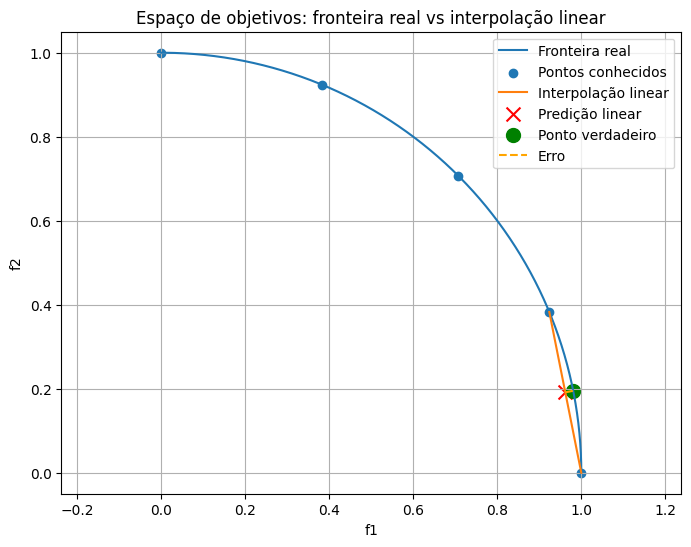

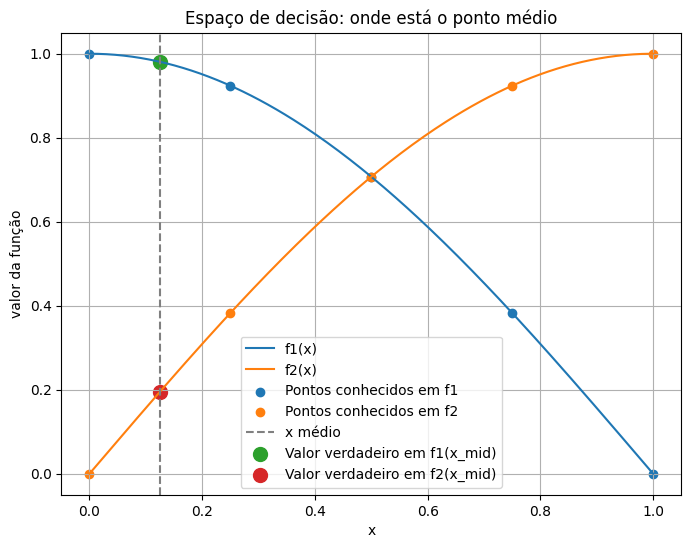

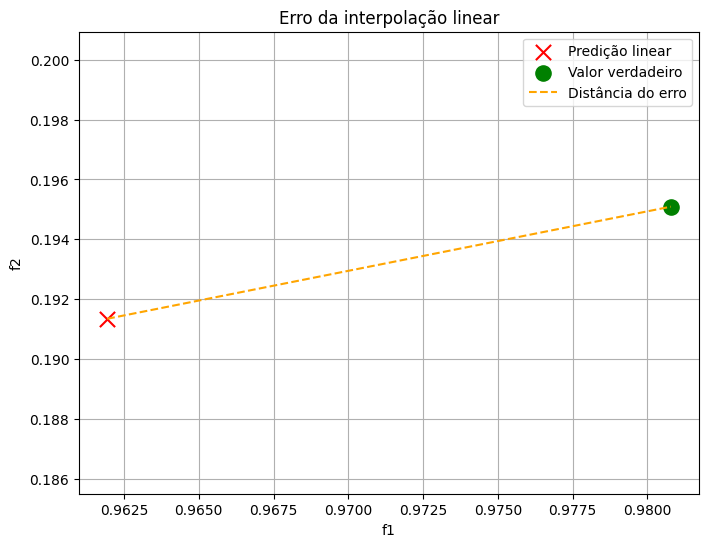

x_mid = 0.1250
Predição linear = (0.9619, 0.1913)
Valor verdadeiro = (0.9808, 0.1951)
Erro geométrico = 0.019215


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. FUNÇÃO BI-OBJETIVO ALTAMENTE NÃO-LINEAR
alpha = 1.0

def f1(x):
    return np.cos((x**alpha) * np.pi / 2)

def f2(x):
    return np.sin((x**alpha) * np.pi / 2)

# 2. O TERRITÓRIO REAL
x_real = np.linspace(0, 1, 200)
y1_real = f1(x_real)
y2_real = f2(x_real)

# 3. PONTOS CONHECIDOS
x_conhecidos = np.linspace(0, 1, 5)
y1_conhecidos = f1(x_conhecidos)
y2_conhecidos = f2(x_conhecidos)

# 4. FALHA DA INTERPOLAÇÃO LINEAR
idx_a, idx_b = 0, 1
x_a, x_b = x_conhecidos[idx_a], x_conhecidos[idx_b]

x_mid = (x_a + x_b) / 2

# previsão linear = ponto médio entre os valores em y
y1_linear_pred = (y1_conhecidos[idx_a] + y1_conhecidos[idx_b]) / 2
y2_linear_pred = (y2_conhecidos[idx_a] + y2_conhecidos[idx_b]) / 2

# 5. VALOR VERDADEIRO
y1_verdadeiro = f1(x_mid)
y2_verdadeiro = f2(x_mid)

# ---------------------------------------------------
# GRÁFICO 1: Fronteira real no espaço de objetivos
# ---------------------------------------------------
plt.figure(figsize=(8, 6))
plt.plot(y1_real, y2_real, label='Fronteira real')
plt.scatter(y1_conhecidos, y2_conhecidos, label='Pontos conhecidos')
plt.plot(
    [y1_conhecidos[idx_a], y1_conhecidos[idx_b]],
    [y2_conhecidos[idx_a], y2_conhecidos[idx_b]],
    label='Interpolação linear'
)
plt.scatter(y1_linear_pred, y2_linear_pred, s=100, marker='x', label='Predição linear', color='red')
plt.scatter(y1_verdadeiro, y2_verdadeiro, s=100, marker='o', label='Ponto verdadeiro', color='green')
plt.plot(
    [y1_linear_pred, y1_verdadeiro],
    [y2_linear_pred, y2_verdadeiro],
    linestyle='--',
    label='Erro',
    color='orange'
)

plt.xlabel('f1')
plt.ylabel('f2')
plt.title('Espaço de objetivos: fronteira real vs interpolação linear')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

# ---------------------------------------------------
# GRÁFICO 2: O que acontece no espaço de decisão (x)
# ---------------------------------------------------
plt.figure(figsize=(8, 6))
plt.plot(x_real, y1_real, label='f1(x)')
plt.plot(x_real, y2_real, label='f2(x)')
plt.scatter(x_conhecidos, y1_conhecidos, label='Pontos conhecidos em f1')
plt.scatter(x_conhecidos, y2_conhecidos, label='Pontos conhecidos em f2')
plt.axvline(x_mid, linestyle='--', label='x médio', color='gray')
plt.scatter(x_mid, y1_verdadeiro, s=100, marker='o', label='Valor verdadeiro em f1(x_mid)')
plt.scatter(x_mid, y2_verdadeiro, s=100, marker='o', label='Valor verdadeiro em f2(x_mid)')

plt.xlabel('x')
plt.ylabel('valor da função')
plt.title('Espaço de decisão: onde está o ponto médio')
plt.legend()
plt.grid(True)
plt.show()

# ---------------------------------------------------
# GRÁFICO 3: comparação isolada entre previsão e verdade
# ---------------------------------------------------
plt.figure(figsize=(8, 6))
plt.scatter(y1_linear_pred, y2_linear_pred, s=120, marker='x', label='Predição linear', color='red')
plt.scatter(y1_verdadeiro, y2_verdadeiro, s=120, marker='o', label='Valor verdadeiro', color='green')
plt.plot(
    [y1_linear_pred, y1_verdadeiro],
    [y2_linear_pred, y2_verdadeiro],
    linestyle='--',
    label='Distância do erro',
    color='orange'
)

plt.xlabel('f1')
plt.ylabel('f2')
plt.title('Erro da interpolação linear')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()

# ERRO NUMÉRICO
erro = np.sqrt((y1_linear_pred - y1_verdadeiro)**2 + (y2_linear_pred - y2_verdadeiro)**2)
print(f"x_mid = {x_mid:.4f}")
print(f"Predição linear = ({y1_linear_pred:.4f}, {y2_linear_pred:.4f})")
print(f"Valor verdadeiro = ({y1_verdadeiro:.4f}, {y2_verdadeiro:.4f})")
print(f"Erro geométrico = {erro:.6f}")